# Notebook 3 - Treinamento de modelos de machine learning

Importando bibliotecas


In [11]:
# Manipulação dos dados
import pandas as pd
import numpy as np

# Visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay
)

# Tratamento de desbalanceamento
from imblearn.over_sampling import SMOTE

# Ignorar warnings chatos
import warnings
warnings.filterwarnings('ignore')

Lendo o dataset .parquet:

In [12]:
data = pd.read_parquet('../data/features/dados_modelo.parquet')
data.head()

,inadimplente,uso_credito_rotativo,idade,atrasos_30_59_dias,razao_divida_renda,renda_mensal,linhas_credito_abertas,atrasos_90_dias_ou_mais,emprestimos_imobiliarios,atrasos_60_89_dias,num_dependentes,razao_extrema,total_atrasos,tem_atraso_grave,renda_per_capita,faixa_jovem,faixa_adulto,faixa_meia_idade,faixa_senior
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,2,0,3040.0,0,1,0,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0,0,1300.0,0,1,0,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,2,1,3042.0,0,1,0,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,0,3300.0,1,0,0,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,1,0,63588.0,0,0,1,0


## Train-test Split

In [13]:
X = data.drop(columns=['inadimplente'])
y = data['inadimplente']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


Verificando se funcionou:

In [14]:
print(f"Treino: {len(X_train)} amostras")
print(f"Teste: {len(X_test)} amostras")
print(f"\nProporção classe 1 no treino: {y_train.mean():.4f}")
print(f"Proporção classe 1 no teste: {y_test.mean():.4f}")

Treino: 119512 amostras
Teste: 29878 amostras

Proporção classe 1 no treino: 0.0670
Proporção classe 1 no teste: 0.0670


## Criando um modelo base para comparações futuras:

In [15]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27876
           1       0.59      0.16      0.26      2002

    accuracy                           0.94     29878
   macro avg       0.77      0.58      0.61     29878
weighted avg       0.92      0.94      0.92     29878



Matriz de confusão do modelo base:

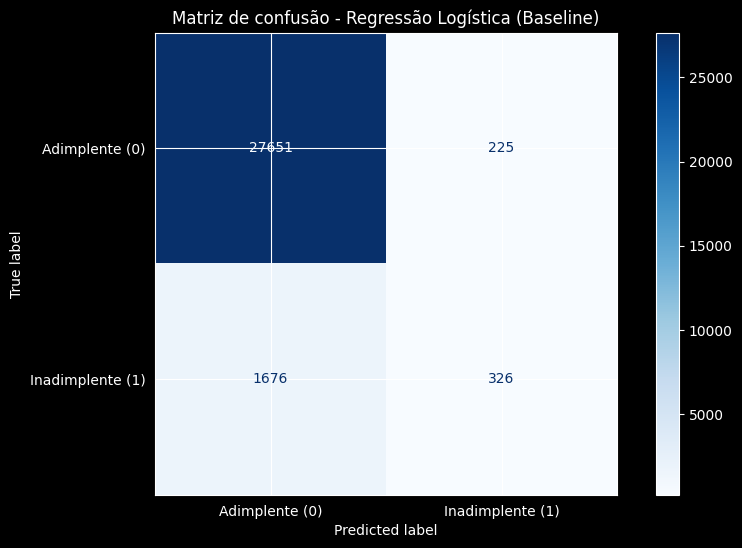

In [16]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels=['Adimplente (0)', 'Inadimplente (1)']
)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de confusão - Regressão Logística (Baseline)')
plt.show()

## Normalização

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Média X_train_scaled: {X_train_scaled.mean():.4f}")
print(f"Desvio padrão X_train_scaled: {X_train_scaled.std():.4f}")

Média X_train_scaled: -0.0000
Desvio padrão X_train_scaled: 1.0000


## SMOTE

In [19]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Antes SMOTE: {y_train.value_counts().to_dict()}")
print(f"Depois SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")

Antes SMOTE: {0: 111505, 1: 8007}
Depois SMOTE: {0: 111505, 1: 111505}


## F2 Score e Reavaliando o Modelo de Regressão Logística

In [23]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

f2 = fbeta_score(y_test, y_pred, beta=2)

print(f"F2-score: {f2:.4f} \n")
print(classification_report(y_test, y_pred))

F2-score: 0.5020 

              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27876
           1       0.22      0.75      0.34      2002

    accuracy                           0.80     29878
   macro avg       0.60      0.78      0.61     29878
weighted avg       0.93      0.80      0.85     29878



## Random Forest, XGBoost

In [24]:
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_scaled)

xgb_model = XGBClassifier(random_state=42, n_jobs=-1, eval_metric = 'logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

Criando função de avaliação do modelo:

In [28]:
def avaliar_modelo(nome, y_test, y_pred):
    print(f"{nome}")
    print(f"F2-Score:  {fbeta_score(y_test, y_pred, beta=2):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print()

Avaliando os resultados dos dois modelos:

In [32]:
avaliar_modelo("Regressão Logística", y_test, y_pred)
avaliar_modelo("Random Forest", y_test, y_pred_rf)
avaliar_modelo("XGB Classifier", y_test, y_pred_xgb)


Regressão Logística
F2-Score:  0.5020
Recall:    0.7512
Precision: 0.2157
F1-Score:  0.3352

Random Forest
F2-Score:  0.3966
Recall:    0.4106
Precision: 0.3489
F1-Score:  0.3772

XGB Classifier
F2-Score:  0.3476
Recall:    0.3317
Precision: 0.4303
F1-Score:  0.3746



## Ajuste de Threshold

In [33]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

print("Threshold | F2-Score | Recall | Precision")
print("-" * 45)

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    f2 = fbeta_score(y_test, y_pred_thresh, beta=2)
    rec = recall_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    print(f"   {thresh:.1f}    |  {f2:.4f}  | {rec:.4f} |  {prec:.4f}")

Threshold | F2-Score | Recall | Precision
---------------------------------------------
   0.1    |  0.2775  | 0.9940 |  0.0715
   0.2    |  0.3572  | 0.9520 |  0.1021
   0.3    |  0.4275  | 0.8841 |  0.1394
   0.4    |  0.4757  | 0.8242 |  0.1768
   0.5    |  0.5020  | 0.7512 |  0.2157


## Testando alternativas para aumentar o f2-score

Testando class_weight = 'balanced' ao invés do SMOTE:

In [35]:
model_balanced = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
y_prob_balanced = model_balanced.predict_proba(X_test_scaled)[:,1]

avaliar_modelo("LogReg (class_weight = 'balanced')", y_test, y_pred_balanced)

LogReg (class_weight = 'balanced')
F2-Score:  0.5044
Recall:    0.7488
Precision: 0.2188
F1-Score:  0.3387



Testando XGBoost com scale_pos_weight:

In [37]:
weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_balanced = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=weight,
    eval_metric='logloss'
)

xgb_balanced.fit(X_train_scaled, y_train)

y_pred_xgb_bal = xgb_balanced.predict(X_test_scaled)
avaliar_modelo("XGBoost (scale_pos_weight)", y_test, y_pred_xgb_bal)

XGBoost (scale_pos_weight)
F2-Score:  0.5016
Recall:    0.7053
Precision: 0.2327
F1-Score:  0.3500

